In [1]:
import numpy as np
import matplotlib.pyplot as plt

from alibz.peaky_maker import PeakyMaker
from alibz.peaky_finder import PeakyFinder
from alibz.peaky_indexer import PeakyIndexer

In [2]:
maker = PeakyMaker(dbpath='db')

In [3]:
fracs = np.zeros(92)
fracs[36] = 1 # lithium, element 3
maker_x, maker_y, _ = maker.peak_maker(fracs=fracs, voigt_sig=0.01, voigt_gam=0.0)

(780.0, 781.0)

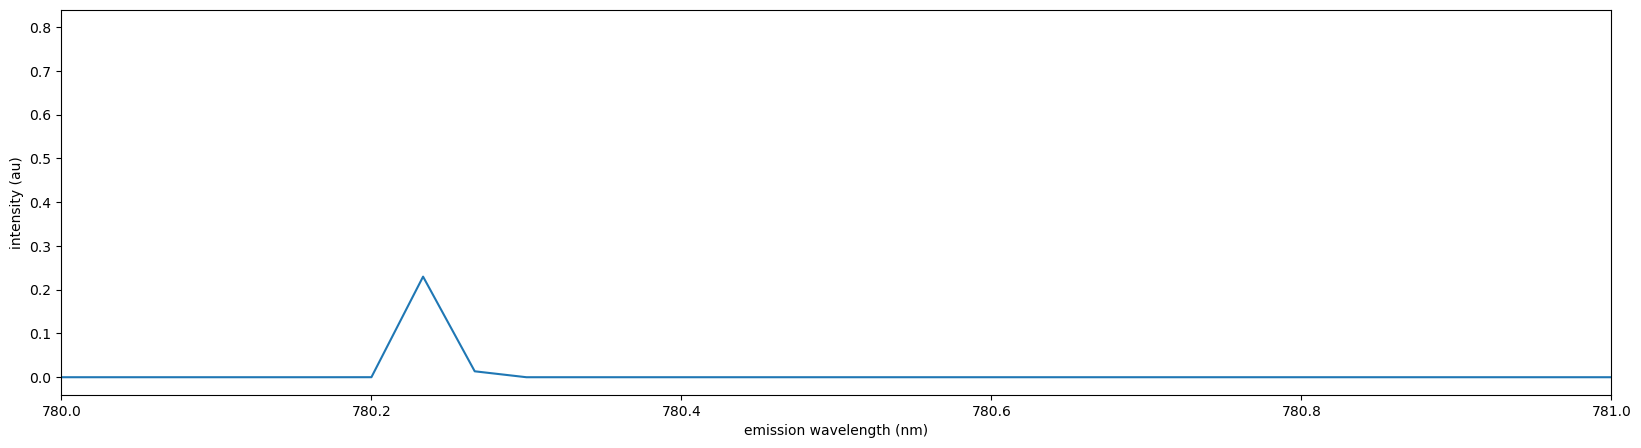

In [4]:
plt.figure(figsize=(20,5))
plt.plot(maker_x, maker_y)
plt.xlabel('emission wavelength (nm)')
plt.ylabel('intensity (au)')
plt.xlim([780,781])

In [5]:
path = '/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/'
finder = PeakyFinder(path)
indexer = PeakyIndexer(finder)

In [6]:
indexer.peak_interference(780.2, ground_state=True)

[['Rb',
  np.float64(1.0),
  np.float64(780.2415),
  780.2,
  np.float64(0.9991183888476739),
  np.float64(8.183269843682805)]]

In [7]:
finder.data.load_data()

array([[[180.        , 180.03333333, 180.06666667, ..., 960.93333333,
         960.96666667, 961.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]],

       [[180.        , 180.03333333, 180.06666667, ..., 960.93333333,
         960.96666667, 961.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]],

       [[180.        , 180.03333333, 180.06666667, ..., 960.93333333,
         960.96666667, 961.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]],

       ...,

       [[180.        , 180.03333333, 180.06666667, ..., 960.93333333,
         960.96666667, 961.        ],
        [  0.        ,   0.        ,   0.        , ...,   0.        ,
           0.        ,   0.        ]],

       [[180.        , 180.03333333, 180.06666667, ..., 960.93333333,
         960.96666667, 961.        ],
       

In [8]:
testwavelength = finder.data.data[10,0]
testdata = finder.data.data[10, 1]

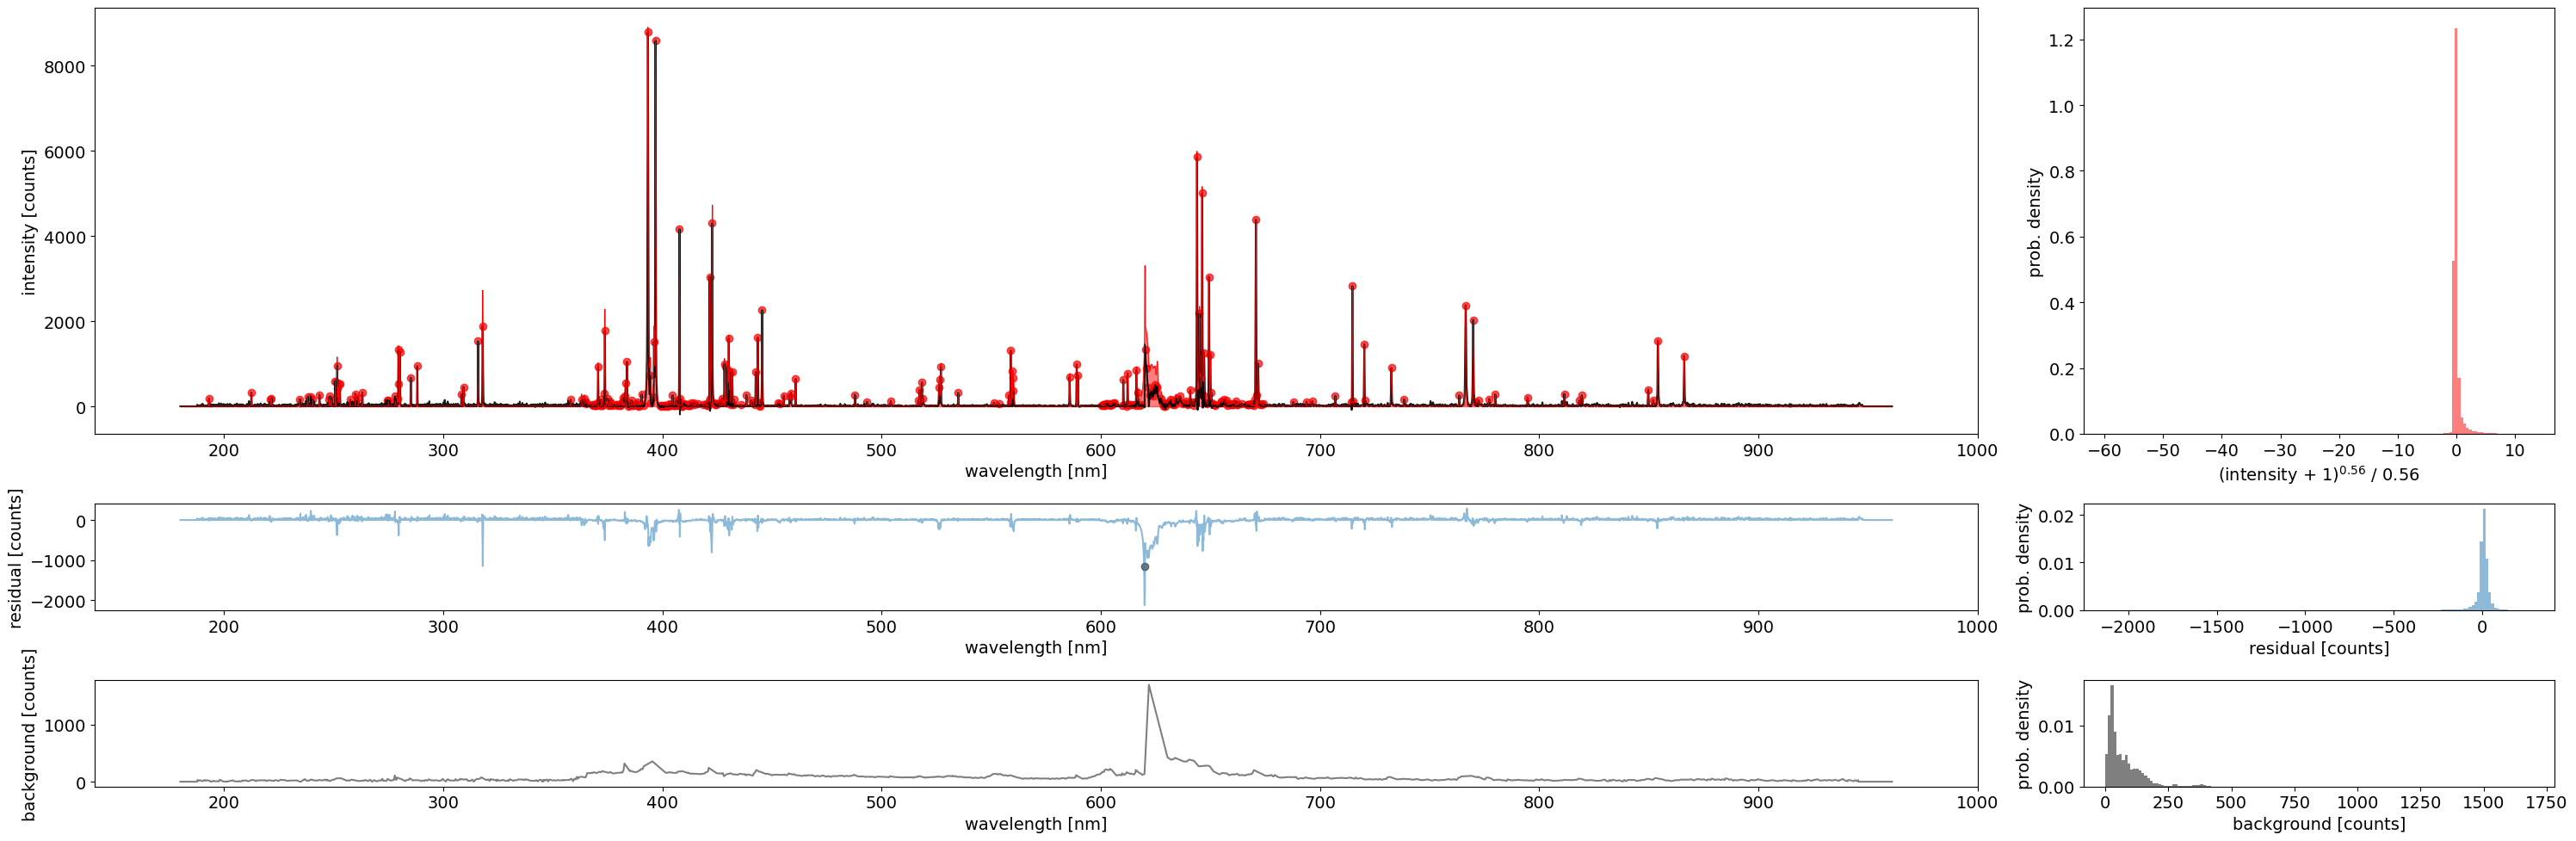

In [9]:
finder_dict = finder.fit_spectrum_data(25, n_sigma=0.5)

In [10]:
stats = indexer.ion_indexer(finder_dict["sorted_parameter_array"], element="Li", ion=1.0)

In [11]:
stats

{'matches': [{'obs_int_sum': 0.3373397357548102,
   'predicted_positions': [670.961, 670.976],
   'predicted_intensities': [0.2391358955036423, 0.05978397387591058],
   'predicted_intensity_sum': 0.2989198693795529,
   'intensity_ratio_obs_over_pred': 1.128528981546134},
  {'obs_int_sum': 0.06581522630442517,
   'predicted_positions': [383.667, 383.672],
   'predicted_intensities': [0.0008427125620892789, 0.0016854251241785578],
   'predicted_intensity_sum': 0.0025281376862678366,
   'intensity_ratio_obs_over_pred': 26.033086196972484},
  {'obs_int_sum': 0.01568625276308819,
   'predicted_positions': [687.497, 687.497],
   'predicted_intensities': [0.00018150732106538315, 4.50527100501576e-05],
   'predicted_intensity_sum': 0.00022656003111554075,
   'intensity_ratio_obs_over_pred': 69.23662874626169},
  {'obs_int_sum': 0.009048319881879574,
   'predicted_positions': [374.764, 374.769],
   'predicted_intensities': [0.0005461425642770903, 0.0010939057296351217],
   'predicted_intensity_

In [12]:
indexer.peak_interference(622.2333,ground_state=False)

[['Cu',
  np.float64(2.0),
  np.float64(621.86585),
  622.2333,
  np.float64(0.9347701161532136),
  np.float64(8.929418925714293)],
 ['Cu',
  np.float64(2.0),
  np.float64(622.15695),
  622.2333,
  np.float64(0.9970933874016934),
  np.float64(8.81954393554187)],
 ['Ca',
  np.float64(3.0),
  np.float64(621.5716),
  622.2333,
  np.float64(0.8035958221277044),
  np.float64(8.44715803134222)],
 ['Cs',
  np.float64(3.0),
  np.float64(622.491),
  622.2333,
  np.float64(0.9673405779191753),
  np.float64(8.403120521175818)],
 ['Co',
  np.float64(2.0),
  np.float64(623.1145),
  622.2333,
  np.float64(0.6785370163785157),
  np.float64(8.380211241711606)],
 ['Al',
  np.float64(2.0),
  np.float64(622.792),
  622.2333,
  np.float64(0.8554968694316867),
  np.float64(8.27415784926368)],
 ['N',
  np.float64(4.0),
  np.float64(622.161),
  622.2333,
  np.float64(0.9973897675963375),
  np.float64(8.117271295655764)],
 ['Ti',
  np.float64(1.0),
  np.float64(622.21957),
  622.2333,
  np.float64(0.999911558

In [13]:
indexer.anchor_peaks(finder_dict['sorted_parameter_array'])

{'La': {'2.0': [407.74822682978237, 430.2333333334678],
  '1.0': [365.03333333341567, 385.26381271855035, 403.76445022132026]},
 'Hf': {'1.0': [445.4624640815555, 363.1333333334144, 368.3284584775772]},
 'Sc': {'1.0': [624.2333333334306, 399.76666666677664, 402.1080905791678],
  '2.0': [364.3740746097831]},
 'Cr': {'5.0': [645.4596424450502, 623.3666666667649]},
 'Ce': {'2.0': [394.40000000010593, 371.6666666667545]},
 'Mo': {'1.0': [315.87272057337526, 379.8875434895236]},
 'Tm': {'1.0': [318.0333333333785,
   252.81452167623115,
   409.46666666678436,
   374.5173437305795,
   371.99286534486555,
   388.9333333334349,
   375.26666666675715,
   410.6333333334522,
   420.4407884942214],
  '2.0': [376.3660191266645]},
 'Mn': {'1.0': [279.5060456142838, 280.2306807547657, 403.10000000011263],
  '5.0': [602.5333333334503]},
 'Dy': {'1.0': [626.133333333429, 658.1717684969747]},
 'Tc': {'1.0': [429.86174314649884], '2.0': [261.14446323359516]},
 'Er': {'2.0': [383.200000000097],
  '1.0': [6

In [14]:
test_dict = indexer.spectrum_match(finder_dict['sorted_parameter_array'][0:5])

In [15]:
test_dict

{'status': 'Optimal',
 'reference_scales': array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.77119966, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ]),
 'normalized_reference_scales': array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.       

## Indexing Setup

Load PCA results from `peaky_data.ipynb` and fit a spectrum to provide
inputs for the indexing pipeline.

In [ ]:
import pickle
from scipy.special import voigt_profile as voigt
from scipy.interpolate import interp1d

# --- Load PCA results ---
RESULTS_FILE = 'jobs/corpus_pca_05x_10pc.pkl'
with open(RESULTS_FILE, 'rb') as f:
    results = pickle.load(f)

stats      = results['width_stats']
components = results['components']
mean_peak  = results['mean_peak']
n_comp     = len(results['explained_variance_ratio'])
n_window_pts = components.shape[1]

# --- Fit a spectrum ---
path = '/Users/mwhittaker/Library/CloudStorage/GoogleDrive-mwhittaker@lbl.gov/My Drive/Postdocs/Xuan Cao/Data/LIBS/MW2-112/raw/'
finder = PeakyFinder(path)
finder.data.load_data()

spectrum_idx = 25
x = finder.data.data[spectrum_idx, 0]
y = finder.data.data[spectrum_idx, 1]

fit_dict = finder.fit_spectrum(x, y, n_sigma=0, subtract_background=True, plot=False)
peak_params = np.array(list(fit_dict['spectrum_dictionary'].values()))
print(f'Fitted {peak_params.shape[0]} peaks')

# --- Project peaks onto PCA basis ---
half_window = stats['smallest_mode_mean'] * 0.5
wl_lo, wl_hi = x[0], x[-1]
x_fixed = np.linspace(0, 1, n_window_pts)
peak_table = []

for i in range(peak_params.shape[0]):
    amp, mu, sigma, gamma = peak_params[i]
    lo, hi = mu - half_window, mu + half_window
    if lo < wl_lo or hi > wl_hi:
        continue
    mask = (x >= lo) & (x <= hi)
    wl_win = x[mask]
    int_win = y[mask].copy()
    if len(wl_win) < 5:
        continue
    baseline = np.linspace(int_win[0], int_win[-1], len(int_win))
    int_win -= baseline
    peak_range = np.max(int_win) - np.min(int_win)
    if peak_range <= 0:
        continue
    int_win -= np.min(int_win)
    int_win /= peak_range
    x_norm_local = np.linspace(0, 1, len(wl_win))
    window = interp1d(x_norm_local, int_win, kind='linear')(x_fixed)
    scores = (window - mean_peak) @ components.T
    entry = {'mu': mu, 'amp': amp, 'window': window}
    for j, s in enumerate(scores):
        entry[f'PC{j+1}'] = s
    peak_table.append(entry)

print(f'Projected {len(peak_table)} peaks onto {n_comp} PCs')

## 5. Peak Indexing Pipeline (Stages 1-4)

Run the physics-driven indexer on the fitted spectrum:

1. **Self-absorption** — flag peaks with extreme PC3/PC6 scores (flat-top signatures)
2. **Anchor identification** — find unambiguous ground-state peaks matching a single element
3. **Boltzmann temperature** — estimate plasma T from intensity ratios of anchor lines
4. **Candidate ranking** — for each non-anchor peak, score candidates on proximity, FWHM/lineshape, Boltzmann intensity, and consistency with anchored elements

In [ ]:
from alibz.peaky_indexer_v2 import PeakyIndexerV2

# Build PCA scores for this spectrum's peaks
pca_scores_spectrum = np.array([
    (p['window'] - mean_peak) @ components.T for p in peak_table
])

print(f"Input: {peak_params.shape[0]} fitted peaks, "
      f"{pca_scores_spectrum.shape[0]} with PCA scores ({n_comp} PCs)")

# Run indexing pipeline
indexer = PeakyIndexerV2(
    peak_array=peak_params,
    pca_scores=pca_scores_spectrum,
    dbpath='db',
    temperature=10000.0,
)

result = indexer.run(
    shift_tolerance=0.1,
    max_ion_stage=2,
    top_n=20,
    min_found_fraction=0.3,
    verbose=True,
)

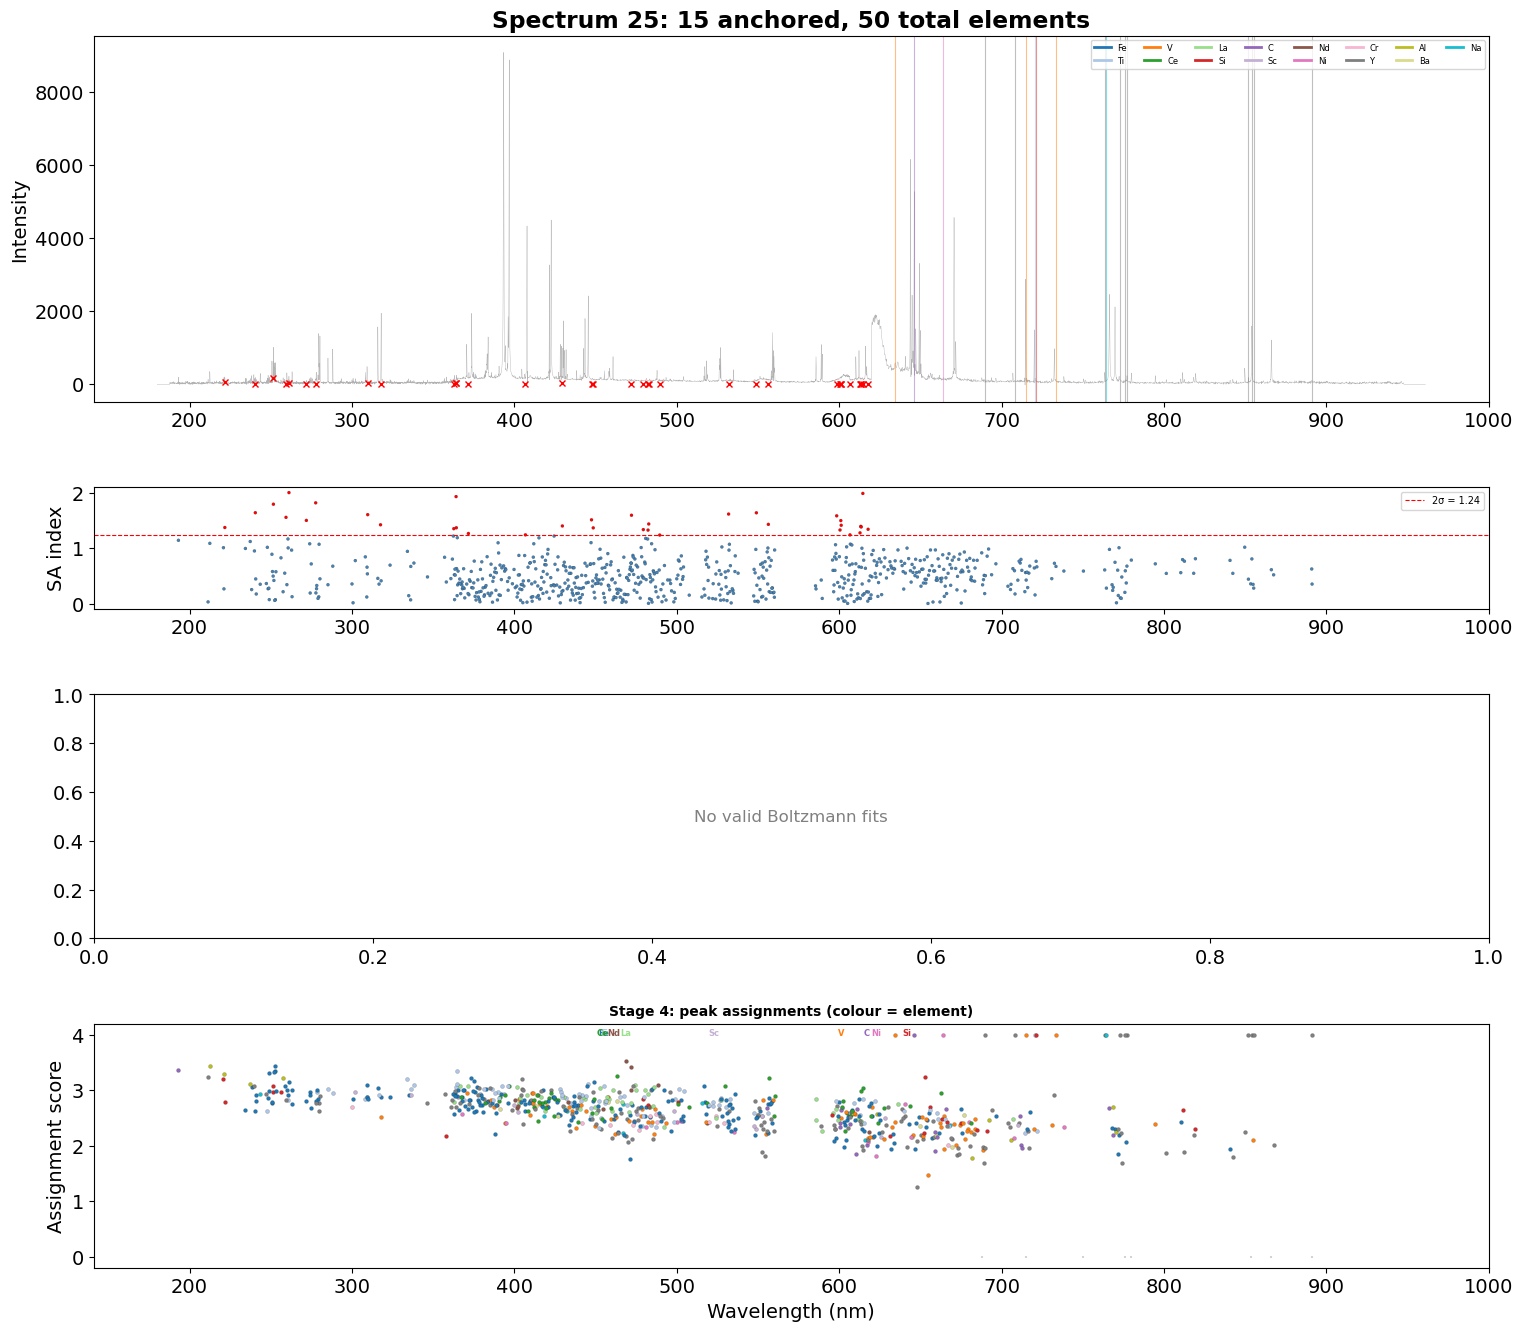


Element  Total  Anchor  Ranked
------------------------------
Fe        207       0     207
Ti         85       1      84
V          73       3      70
Ce         49       0      49
La         46       0      46
Si         22       1      21
C          21       1      20
Sc         14       0      14
Nd         14       0      14
Ni         13       1      12
Cr         12       0      12
Y          12       0      12
Al         10       0      10
Ba         10       0      10
Na         10       1       9
Mn          9       0       9
Eu          8       0       8
Pr          7       0       7
Ta          7       0       7
Hf          7       0       7


In [28]:
# --- Visualise indexer results (Stages 1-4) ---
from collections import Counter

fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(4, 1, height_ratios=[3, 1, 2, 2], hspace=0.35)
ax_spec = fig.add_subplot(gs[0])
ax_sa = fig.add_subplot(gs[1], sharex=ax_spec)
ax_boltz = fig.add_subplot(gs[2])
ax_elem = fig.add_subplot(gs[3], sharex=ax_spec)

# --- Colour map for top elements ---
el_counts = Counter()
for rec in indexer.peaks:
    el = rec.assigned_element or rec.anchor_element
    if el:
        el_counts[el] += 1
top_elements = [el for el, _ in el_counts.most_common(15)]
cmap_tab = plt.cm.tab20
element_colors = {el: cmap_tab(i / 15) for i, el in enumerate(top_elements)}

# --- Panel 1: Spectrum with anchors ---
ax = ax_spec
ax.plot(x, y, 'k-', lw=0.3, alpha=0.3)
for rec in indexer.peaks:
    if rec.is_anchor:
        color = element_colors.get(rec.anchor_element, 'gray')
        ax.axvline(rec.wavelength, color=color, alpha=0.5, lw=0.8)
for rec in indexer.peaks:
    if rec.is_self_absorbed:
        ax.plot(rec.wavelength, rec.amplitude, 'rx', ms=5, mew=1)
for el in top_elements:
    ax.axvline(np.nan, color=element_colors[el], lw=2, label=el)
ax.set_ylabel('Intensity')
ax.set_title(f'Spectrum {spectrum_idx}: {len(result["confirmed_elements"])} anchored, '
             f'{len(result["all_elements"])} total elements', fontweight='bold')
ax.legend(fontsize=6, ncol=min(len(top_elements), 8), loc='upper right')

# --- Panel 2: Self-absorption index ---
ax = ax_sa
wls = [rec.wavelength for rec in indexer.peaks]
sa_idx = [rec.self_absorption_index for rec in indexer.peaks]
colors_sa = ['red' if rec.is_self_absorbed else 'steelblue' for rec in indexer.peaks]
ax.scatter(wls, sa_idx, c=colors_sa, s=5, edgecolors='k', linewidths=0.1)
sa_cutoff = np.mean(sa_idx) + 2.0 * np.std(sa_idx)
ax.axhline(sa_cutoff, color='r', ls='--', lw=0.8, label=f'2σ = {sa_cutoff:.2f}')
ax.set_ylabel('SA index')
ax.legend(fontsize=7)

# --- Panel 3: Boltzmann plots ---
ax = ax_boltz
boltz = result['boltzmann_results']
if boltz:
    for key, br in boltz.items():
        el = br.element
        color = element_colors.get(el, 'gray')
        ion_label = ['', 'I', 'II', 'III']
        ion_str = ion_label[int(br.ion)] if int(br.ion) < len(ion_label) else f"{int(br.ion)}"
        entries = indexer.anchors.get(el, {}).get(br.ion, [])
        usable = [e for e in entries if not e['is_self_absorbed']
                  and e['amplitude'] > 0 and e['gA'] > 0]
        if len(usable) < 3:
            continue
        Ek_pts = [e['Ek'] for e in usable]
        y_pts = [np.log(e['amplitude'] * e['wavelength'] / e['gA']) for e in usable]
        ax.scatter(Ek_pts, y_pts, color=color, s=40, edgecolors='k', linewidths=0.5,
                   label=f"{el} {ion_str}: T={br.temperature_K:.0f} K (R²={br.r_squared:.2f})", zorder=3)
        Ek_range = np.linspace(min(Ek_pts) - 0.5, max(Ek_pts) + 0.5, 50)
        ax.plot(Ek_range, br.slope * Ek_range + br.intercept, color=color, ls='--', lw=1)
    T_str = f"Consensus T = {result['consensus_temperature']:.0f} K" if result['consensus_temperature'] else "No consensus T"
    ax.set_title(f"Boltzmann plots — {T_str}", fontsize=10, fontweight='bold')
    ax.set_xlabel('$E_k$ (eV)')
    ax.set_ylabel('$\\ln(I \\cdot \\lambda / gA)$')
    ax.legend(fontsize=7)
else:
    ax.text(0.5, 0.5, 'No valid Boltzmann fits', transform=ax.transAxes,
            ha='center', va='center', fontsize=12, color='gray')

# --- Panel 4: Element assignments (all peaks) ---
ax = ax_elem
for rec in indexer.peaks:
    el = rec.assigned_element or rec.anchor_element
    if el is None:
        ax.scatter(rec.wavelength, 0, c='lightgray', s=3, marker='|')
        continue
    color = element_colors.get(el, 'gray')
    score = rec.assignment_score if not rec.is_anchor else 4.0
    ax.scatter(rec.wavelength, score, c=[color], s=8, edgecolors='k', linewidths=0.1)

ax.set_ylabel('Assignment score')
ax.set_xlabel('Wavelength (nm)')
ax.set_title('Stage 4: peak assignments (colour = element)', fontsize=10, fontweight='bold')
# Add element labels at median wavelength for top elements
for el in top_elements[:10]:
    el_wls = [rec.wavelength for rec in indexer.peaks
              if (rec.assigned_element == el or rec.anchor_element == el)]
    if el_wls:
        ax.text(np.median(el_wls), ax.get_ylim()[1] * 0.95, el,
                fontsize=6, ha='center', color=element_colors[el], fontweight='bold')

plt.show()

# --- Summary ---
print(f"\n{'Element':6s} {'Total':>6s} {'Anchor':>7s} {'Ranked':>7s}")
print('-' * 30)
for el, count in el_counts.most_common(20):
    n_anch = sum(1 for r in indexer.peaks if r.anchor_element == el and r.is_anchor)
    print(f"{el:6s} {count:6d} {n_anch:7d} {count - n_anch:7d}")

## 6. Whole-Pattern Spectral Fitting (v3 Indexer)

Treats the observed peak table as a linear combination of element spectra.
Bayesian optimisation over (T, nₑ, σ, γ) with NNLS for non-negative
concentrations at each step.

In [29]:
from alibz.peaky_indexer_v3 import PeakyIndexerV3

idx3 = PeakyIndexerV3(
    peak_array=peak_params,
    pca_scores=pca_scores_spectrum,
    dbpath='db',
    temperature_init=10000.0,
    ne_init=17.0,
)

fit = idx3.run(
    shift_tolerance=0.1,
    max_ion_stage=2,
    min_gA=100.0,
    n_calls=50,
    verbose=True,
)

Building candidate matrix (tol=0.1, max_ion=2, min_gA=100.0)...
  29496 lines, 143 species, 6549 peak-line overlaps (0.0302% dense)

Bayesian optimisation: 50 evaluations over T=[4000,25000], ne=[14,19]
  eval 10/50: T=4335 K, ne=15.2, σ=0.0799, γ=0.2081, cost=3.14e+07
  eval 20/50: T=13216 K, ne=19.0, σ=0.3000, γ=0.3000, cost=2.92e+07
  eval 30/50: T=13434 K, ne=19.0, σ=0.3000, γ=0.3000, cost=2.92e+07
  eval 40/50: T=13390 K, ne=19.0, σ=0.3000, γ=0.3000, cost=2.92e+07
  eval 50/50: T=13391 K, ne=19.0, σ=0.3000, γ=0.3000, cost=2.92e+07

Best: T=13435 K, ne=19.0, σ=0.3000, γ=0.3000
R² = 0.5699, cost = 2.92e+07
Active species: 66/143
Unexplained peaks: 42/734

Top species:
  Ca   II : c=5.1660e+03  (10 peaks)
  Ca   I  : c=1.4954e+03  (49 peaks)
  Cd   I  : c=8.3383e+02  (4 peaks)
  Sr   II : c=7.8739e+02  (5 peaks)
  B    I  : c=5.9729e+02  (7 peaks)
  Rb   I  : c=5.2320e+02  (4 peaks)
  Sn   II : c=3.4119e+02  (9 peaks)
  N    I  : c=2.6667e+02  (55 peaks)
  Ra   I  : c=2.2028e+02  (6 

In [33]:
# --- Fit summary ---
from collections import Counter

# Aggregate concentrations by element (sum ion stages)
el_conc = {}
for i, sp in enumerate(fit.species):
    if fit.concentrations[i] > 0:
        el_conc[sp.element] = el_conc.get(sp.element, 0) + fit.concentrations[i]

# Peak counts by element
el_peaks = Counter(pa['element'] for pa in fit.peak_assignments if pa['element'])

# Sort by concentration
sorted_els = sorted(el_conc.items(), key=lambda x: -x[1])

print(f"Temperature: {fit.temperature:.0f} K")
print(f"log(nₑ): {fit.ne:.1f}")
print(f"Broadening: σ={fit.sigma:.4f} nm, γ={fit.gamma:.4f} nm")
print(f"R² = {fit.r_squared:.4f}")
print(f"Active species: {int(np.sum(fit.concentrations > 0))}/{len(fit.species)}")
print(f"Unexplained peaks: {len(fit.unexplained_peaks)}/{len(fit.observed)}")
print(f"\n{'Element':8s} {'Conc':>10s} {'Peaks':>6s} {'Conc %':>8s}")
print('-' * 36)
total_c = sum(c for _, c in sorted_els)
for el, c in sorted_els[:25]:
    pct = 100 * c / total_c if total_c > 0 else 0
    print(f"{el:8s} {c:10.1f} {el_peaks.get(el, 0):6d} {pct:7.2f}%")

Temperature: 13435 K
log(nₑ): 19.0
Broadening: σ=0.3000 nm, γ=0.3000 nm
R² = 0.5699
Active species: 66/143
Unexplained peaks: 42/734

Element        Conc  Peaks   Conc %
------------------------------------
Ca           6661.4     59   47.64%
Sr            886.4     31    6.34%
Cd            833.8      4    5.96%
Rb            697.3     18    4.99%
B             597.3      7    4.27%
Mg            383.8     11    2.74%
Sn            341.2      9    2.44%
Al            299.3     19    2.14%
N             266.7     55    1.91%
Dy            229.6     14    1.64%
Ra            223.4      7    1.60%
Na            208.0      4    1.49%
Ba            197.9     36    1.42%
Kr            182.4      6    1.30%
Ce            166.0     80    1.19%
F             158.3     14    1.13%
O             139.1      8    0.99%
Lu            130.5      1    0.93%
Ar            120.3     26    0.86%
Fe            112.8     54    0.81%
S             111.8     20    0.80%
Pr             86.6     38    0.62%
P

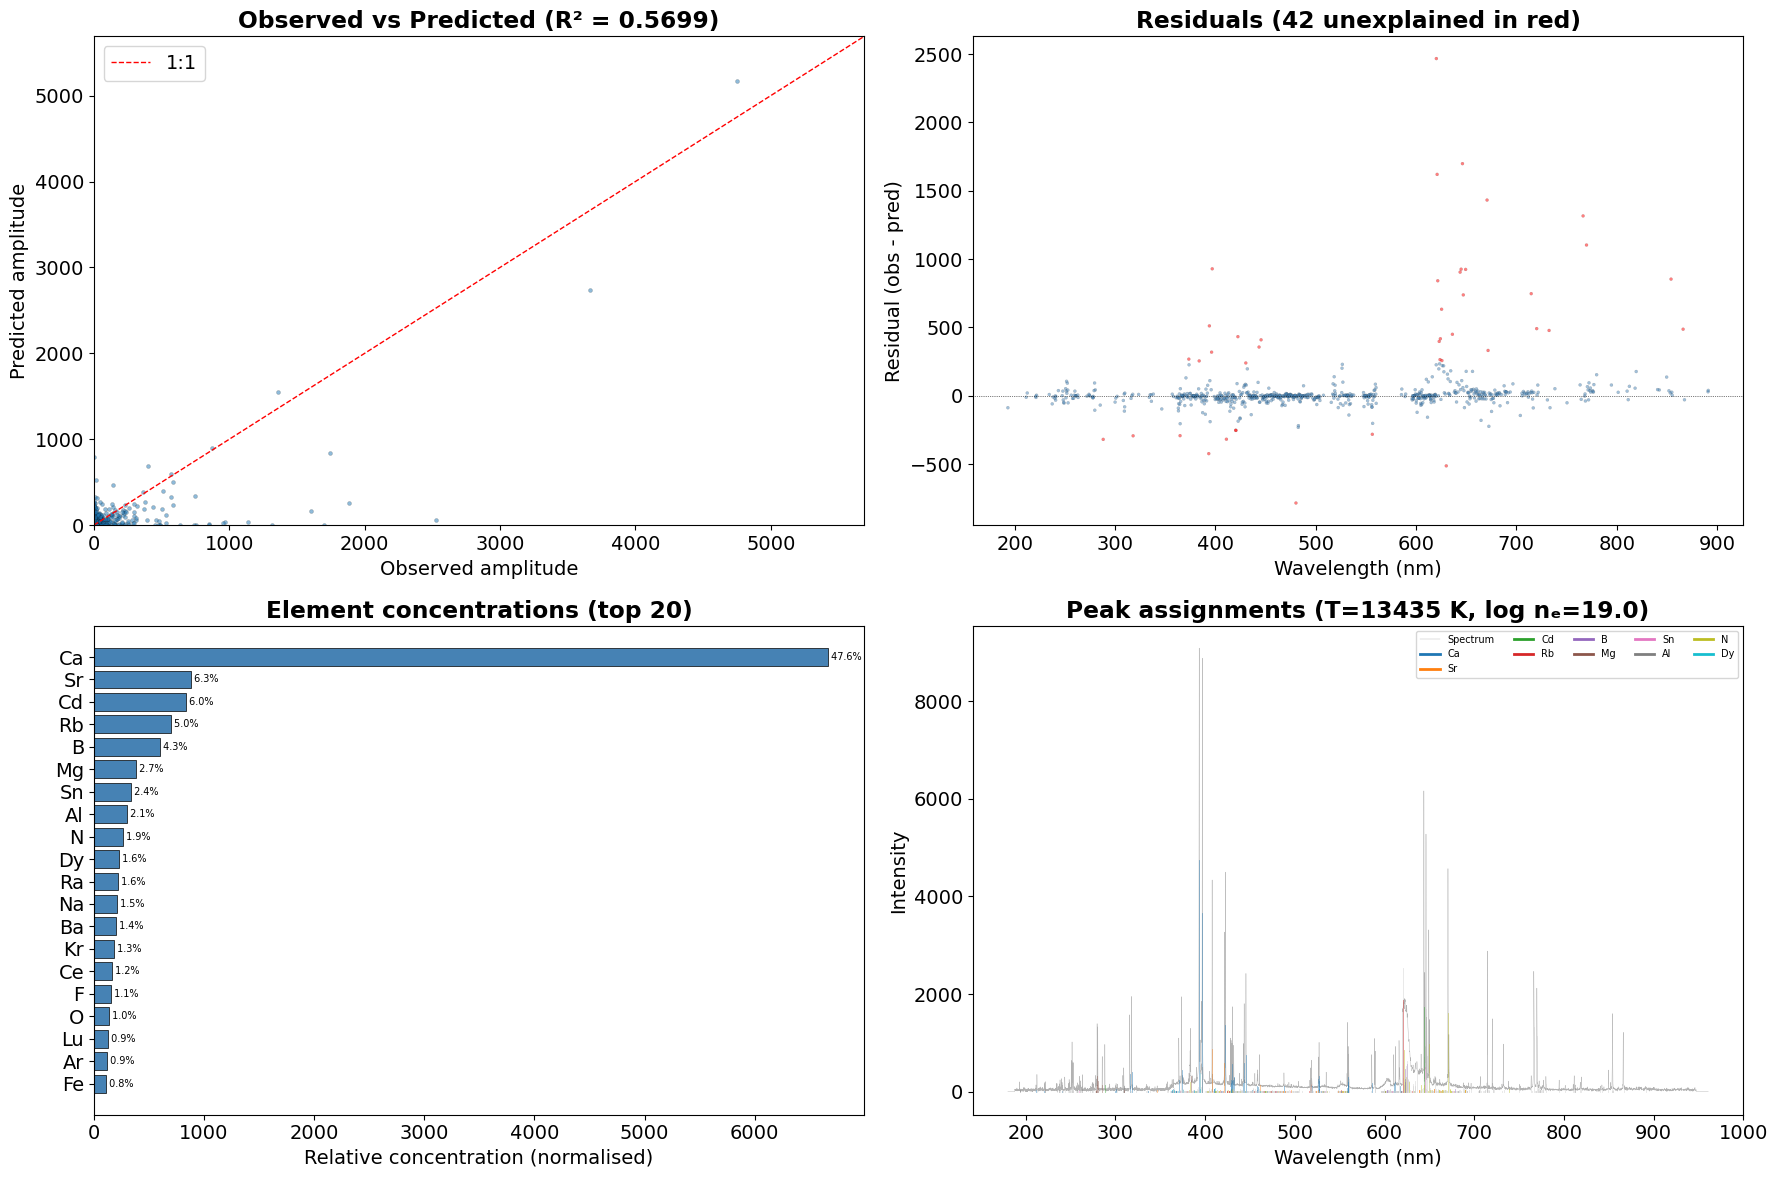

In [34]:
# --- Plot 1: Observed vs Predicted amplitudes ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-left: Observed vs predicted scatter
ax = axes[0, 0]
ax.scatter(fit.observed, fit.predicted, s=8, alpha=0.5, edgecolors='k', linewidths=0.2)
lim = max(fit.observed.max(), fit.predicted.max()) * 1.1
ax.plot([0, lim], [0, lim], 'r--', lw=1, label='1:1')
ax.set_xlabel('Observed amplitude')
ax.set_ylabel('Predicted amplitude')
ax.set_title(f'Observed vs Predicted (R² = {fit.r_squared:.4f})', fontweight='bold')
ax.legend()
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

# Top-right: Residuals vs wavelength
ax = axes[0, 1]
wls = [pv.wavelength for pv in idx3.peaks]
colors = ['red' if i in fit.unexplained_peaks else 'steelblue'
          for i in range(len(fit.residuals))]
ax.scatter(wls, fit.residuals, c=colors, s=5, alpha=0.5, edgecolors='k', linewidths=0.1)
ax.axhline(0, color='k', ls=':', lw=0.5)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Residual (obs - pred)')
ax.set_title(f'Residuals ({len(fit.unexplained_peaks)} unexplained in red)', fontweight='bold')

# Bottom-left: Concentration bar chart (top 20 elements)
ax = axes[1, 0]
top_n = min(20, len(sorted_els))
els = [el for el, _ in sorted_els[:top_n]]
concs = [c for _, c in sorted_els[:top_n]]
bars = ax.barh(range(top_n), concs, color='steelblue', edgecolor='k', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(els)
ax.invert_yaxis()
ax.set_xlabel('Relative concentration (normalised)')
ax.set_title('Element concentrations (top 20)', fontweight='bold')
# Add percentage labels
for i, (el, c) in enumerate(sorted_els[:top_n]):
    pct = 100 * c / total_c if total_c > 0 else 0
    ax.text(c, i, f' {pct:.1f}%', va='center', fontsize=7)

# Bottom-right: Spectrum with coloured peak assignments
ax = axes[1, 1]
ax.plot(x, y, 'k-', lw=0.3, alpha=0.3, label='Spectrum')

# Colour top 10 elements
top10 = [el for el, _ in sorted_els[:10]]
cmap = plt.cm.tab10
el_colors = {el: cmap(i) for i, el in enumerate(top10)}

for pa in fit.peak_assignments:
    el = pa['element']
    if el is None:
        continue
    color = el_colors.get(el, (0.8, 0.8, 0.8, 0.3))
    wl = idx3.peaks[pa['peak_idx']].wavelength
    amp = pa['observed']
    ax.plot([wl, wl], [0, amp], color=color, lw=0.6, alpha=0.5)

for el in top10:
    ax.plot([], [], color=el_colors[el], lw=2, label=el)
ax.legend(fontsize=7, ncol=5, loc='upper right')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Intensity')
ax.set_title(f'Peak assignments (T={fit.temperature:.0f} K, '
             f'log nₑ={fit.ne:.1f})', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# --- Plot 2: Bayesian optimisation convergence ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

costs = fit.convergence_info['all_costs']
ax = axes[0]
ax.plot(costs, 'o-', ms=3, lw=0.8, color='steelblue')
ax.set_xlabel('Evaluation')
ax.set_ylabel('Cost (SSE)')
ax.set_title('Bayesian optimisation convergence', fontweight='bold')
ax.set_yscale('log')

# Running minimum
running_min = np.minimum.accumulate(costs)
ax.plot(running_min, 'r-', lw=1.5, label='Running min')
ax.legend()

# Per-element observed vs predicted (top 8 elements)
ax = axes[1]
top8 = [el for el, _ in sorted_els[:8]]
for el in top8:
    obs_vals = []
    pred_vals = []
    for pa in fit.peak_assignments:
        if pa['element'] == el:
            obs_vals.append(pa['observed'])
            pred_vals.append(pa['total_predicted'])
    if obs_vals:
        color = el_colors.get(el, 'gray')
        ax.scatter(obs_vals, pred_vals, s=15, alpha=0.6,
                   color=color, edgecolors='k', linewidths=0.3, label=el)

lim = max(fit.observed.max(), fit.predicted.max()) * 0.5
ax.plot([0, lim], [0, lim], 'k--', lw=0.5)
ax.set_xlabel('Observed')
ax.set_ylabel('Predicted')
ax.set_title('Per-element obs vs pred (top 8)', fontweight='bold')
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()